## in EDA what things we do
1. Missing Value
2. Explore about the num var
3. Explore about the categorical var
4. Finding Relationships between features

# Types of data values
int64 means integer variable, object means categorical variable/text data/int variable, float64 means floating values.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

using isnull.sum() we can see that there are no null values in any column is this dataset

# basic structure for a dataset:
1. df.shape : tells the no. of (rows,columns).
2. df.head() : fetches the first 5 records.
3. df.tail() : fetches the last 5 records.
4. df.info() : gives infoo about the dataset.
5. df.describe() : tells us meaningful info about the data ex. mean,max,min,median.
6. df.columns : no. of columns.
7. df.dtypes : tells the data type.
8. df.nunique(): tells about unique values in each column.

# Accessing Data with Pandas
1. df
2. df.loc[start:end] : used to fetch the records or rows or also we an write df.loc[3:9,"column name"]
3. df.index


In [2]:
df = pd.read_csv("Heart.csv")

In [50]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [51]:
df.shape

(918, 12)

In [52]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

In [54]:
df.sample()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


In [57]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [65]:
df.duplicated().sum()

np.int64(0)

### the dataset has no duplicate values.

In [60]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [61]:
df.dtypes

Age                 int64
Sex                object
ChestPainType      object
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG         object
MaxHR               int64
ExerciseAngina     object
Oldpeak           float64
ST_Slope           object
HeartDisease        int64
dtype: object

In [68]:
df["ChestPainType"].value_counts()

ChestPainType
ASY    496
NAP    203
ATA    173
TA      46
Name: count, dtype: int64

In [69]:
df["Sex"].value_counts()

Sex
M    725
F    193
Name: count, dtype: int64

In [70]:
df["ExerciseAngina"].value_counts()

ExerciseAngina
N    547
Y    371
Name: count, dtype: int64

In [71]:
df["RestingECG"].value_counts()

RestingECG
Normal    552
LVH       188
ST        178
Name: count, dtype: int64

In [ ]:
df["ST_Slope"].value_counts()

ST_Slope
Flat    460
Up      395
Down     63
Name: count, dtype: int64

# Interpretation
1. Sex : M is more common
2. ChestPainType : ASY is much more common than TA
3. ST_Slope : down is more common than flat/up
4. min cholesterol is 0 which is unlikely!!
5. restingBP is also 0 which is unusual!!

## Validity and Range Checking

The minimum values of Cholesterol and RestingBP are 0, which are unusual values for these measurements. These values will be investigated before performing further analysis.

In [38]:
print("Cholesterol = 0:")
print(df[df["Cholesterol"] == 0])

print("\nRestingBP = 0:")
print(df[df["RestingBP"] == 0])

Cholesterol = 0:
     Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  \
293   65   M           ASY        115            0          0     Normal   
294   32   M            TA         95            0          1     Normal   
295   61   M           ASY        105            0          1     Normal   
296   50   M           ASY        145            0          1     Normal   
297   57   M           ASY        110            0          1         ST   
..   ...  ..           ...        ...          ...        ...        ...   
514   43   M           ASY        122            0          0     Normal   
515   63   M           NAP        130            0          1         ST   
518   48   M           NAP        102            0          1         ST   
535   56   M           ASY        130            0          0        LVH   
536   62   M           NAP        133            0          1         ST   

     MaxHR ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
293     93

In [37]:
print("Number of zero Cholesterol values:", (df["Cholesterol"] == 0).sum())
print("Number of zero RestingBP values:", (df["RestingBP"] == 0).sum())

Number of zero Cholesterol values: 172
Number of zero RestingBP values: 1


In [41]:
df["Cholesterol"] = df["Cholesterol"].replace(0, np.nan)
df["RestingBP"] = df["RestingBP"].replace(0, np.nan)

In [42]:
print(df[["Cholesterol", "RestingBP"]].isnull().sum())

Cholesterol    172
RestingBP        1
dtype: int64


In [43]:
df["Cholesterol"] = df["Cholesterol"].fillna(df["Cholesterol"].median())
df["RestingBP"] = df["RestingBP"].fillna(df["RestingBP"].median())

In [44]:
print(df[["Cholesterol", "RestingBP"]].isnull().sum())

Cholesterol    0
RestingBP      0
dtype: int64


### Cleaning Invalid Values:

Zero values in Cholesterol and RestingBP were treated as invalid values and replaced with missing values. The missing values were then replaced with the median of their respective columns because the median is less affected by extreme values.

# Univariate Analysis begins:

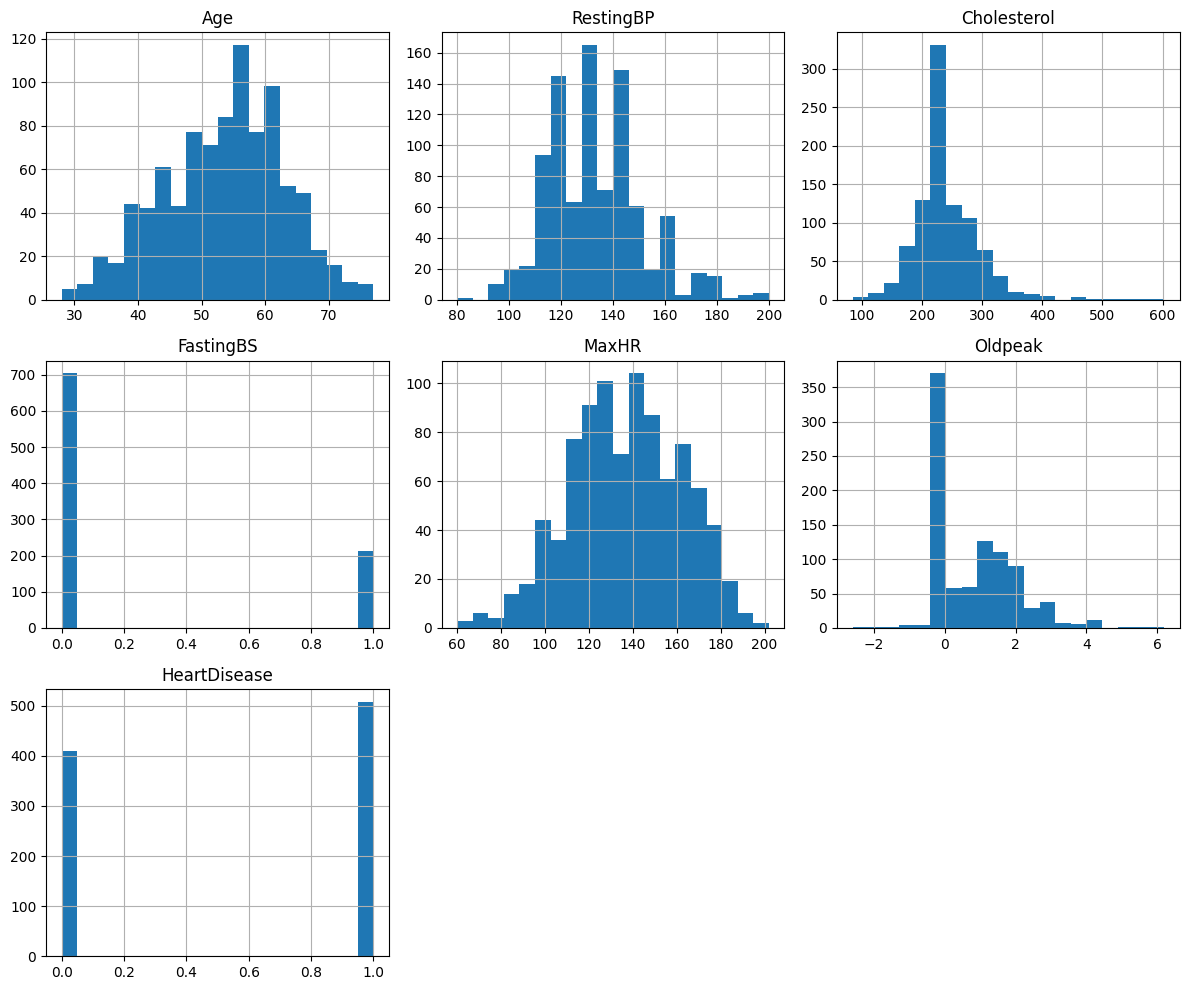

In [45]:
df.hist(figsize=(12, 10), bins=20)
plt.tight_layout()
plt.show()

# Analysis on Categorical Variables:

In [46]:
df["ChestPainType"].value_counts()
df["Sex"].value_counts()
df["ExerciseAngina"].value_counts()
df["RestingECG"].value_counts()
df["ST_Slope"].value_counts()

ST_Slope
Flat    460
Up      395
Down     63
Name: count, dtype: int64

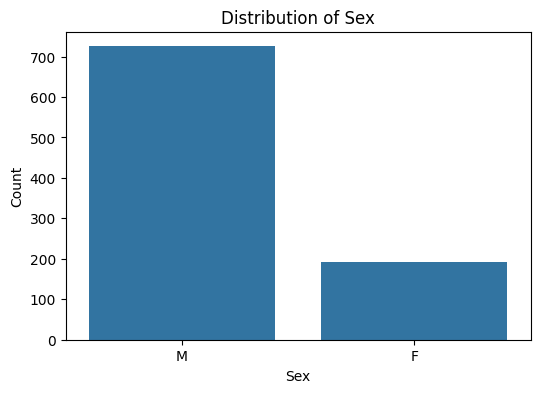

In [47]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Sex")

plt.title("Distribution of Sex")
plt.xlabel("Sex")
plt.ylabel("Count")

plt.show()

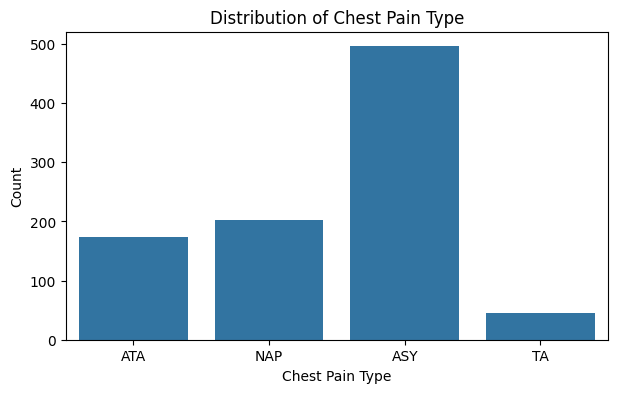

In [48]:
plt.figure(figsize=(7, 4))

sns.countplot(data=df, x="ChestPainType")

plt.title("Distribution of Chest Pain Type")
plt.xlabel("Chest Pain Type")
plt.ylabel("Count")

plt.show()

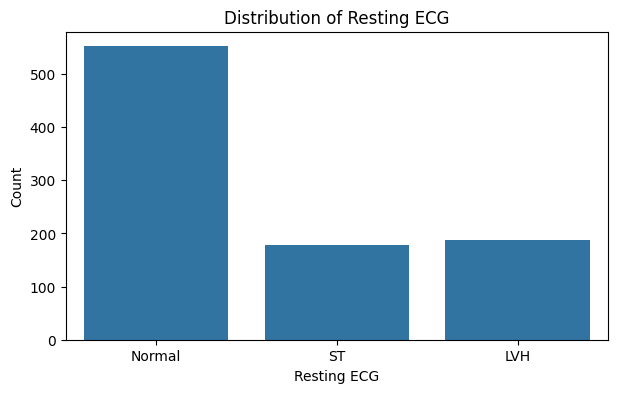

In [49]:
plt.figure(figsize=(7, 4))

sns.countplot(data=df, x="RestingECG")

plt.title("Distribution of Resting ECG")
plt.xlabel("Resting ECG")
plt.ylabel("Count")

plt.show()

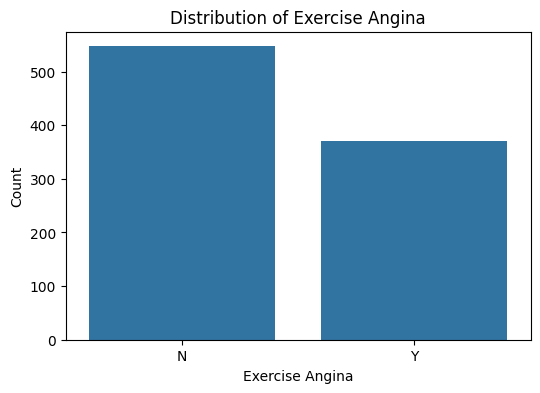

In [50]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="ExerciseAngina")

plt.title("Distribution of Exercise Angina")
plt.xlabel("Exercise Angina")
plt.ylabel("Count")

plt.show()

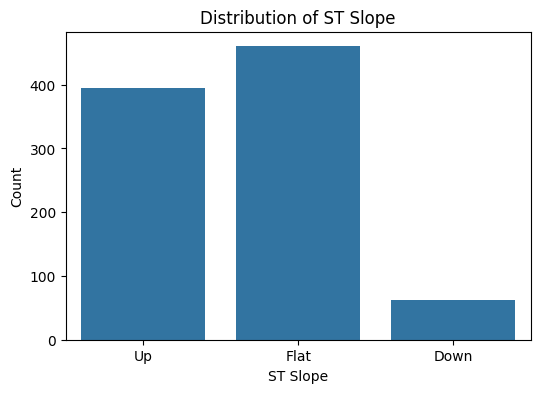

In [51]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="ST_Slope")

plt.title("Distribution of ST Slope")
plt.xlabel("ST Slope")
plt.ylabel("Count")

plt.show()

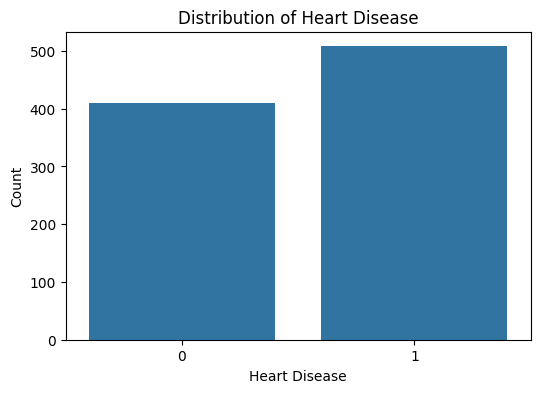

In [52]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="HeartDisease")

plt.title("Distribution of Heart Disease")
plt.xlabel("Heart Disease")
plt.ylabel("Count")

plt.show()

# Analysing the Bivariate:

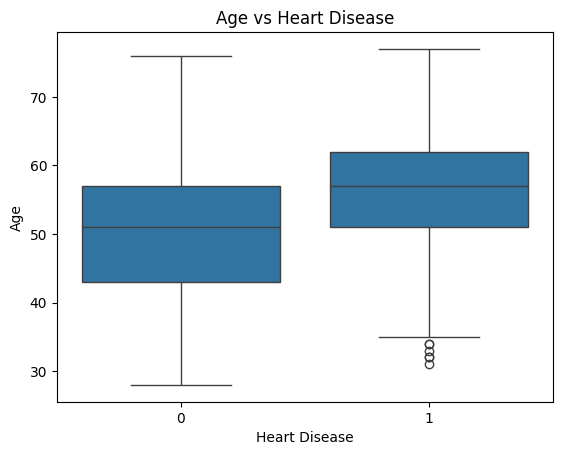

In [55]:
sns.boxplot(data=df, x="HeartDisease", y="Age")

plt.title("Age vs Heart Disease")
plt.xlabel("Heart Disease")
plt.ylabel("Age")

plt.show()

### Insight:
The boxplot shows that patients with heart disease generally have a higher median age than patients without heart disease. This suggests that age may be associated with heart disease in this dataset.

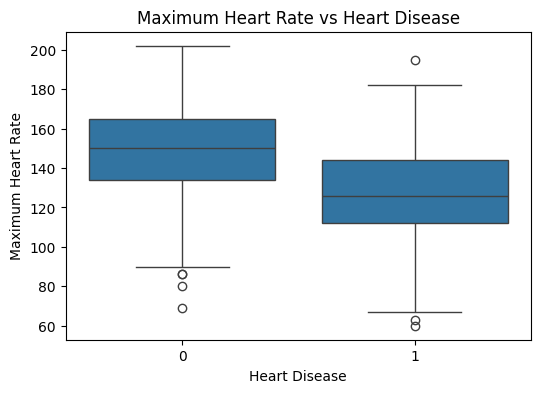

In [56]:
plt.figure(figsize=(6, 4))

sns.boxplot(data=df, x="HeartDisease", y="MaxHR")

plt.title("Maximum Heart Rate vs Heart Disease")
plt.xlabel("Heart Disease")
plt.ylabel("Maximum Heart Rate")

plt.show()

### Insight:
The boxplot shows that maximum heart rate differs between the two heart disease groups. The heart disease group generally has a lower median maximum heart rate. A few outliers are also present in both groups.

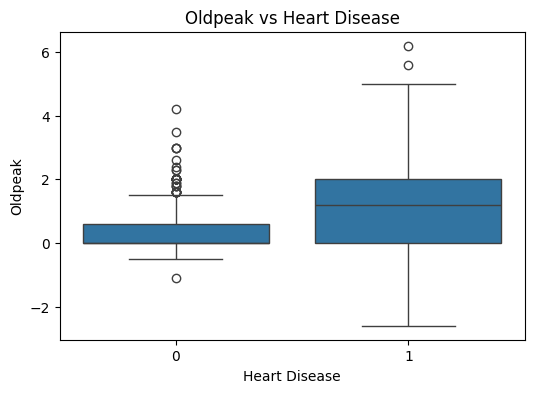

In [57]:
plt.figure(figsize=(6, 4))

sns.boxplot(data=df, x="HeartDisease", y="Oldpeak")

plt.title("Oldpeak vs Heart Disease")
plt.xlabel("Heart Disease")
plt.ylabel("Oldpeak")

plt.show()

### Insight:
The boxplot shows that Oldpeak values are generally higher for patients with heart disease. Several potential outliers are also visible, particularly in the group without heart disease.

## Plots for Categorical Variables:

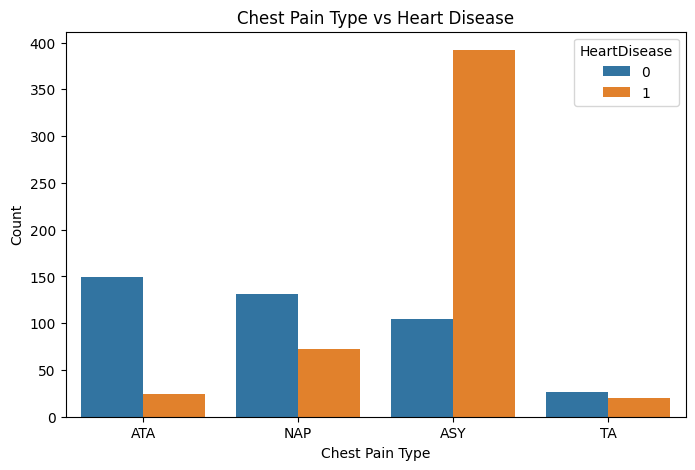

In [58]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="ChestPainType", hue="HeartDisease")

plt.title("Chest Pain Type vs Heart Disease")
plt.xlabel("Chest Pain Type")
plt.ylabel("Count")

plt.show()

### Insight:
The distribution of heart disease varies across different chest pain types. The ASY category has a much higher number of patients with heart disease, while ATA has more patients without heart disease. This suggests that ChestPainType may be associated with HeartDisease in this dataset.

# Correlation Analysis:

In [60]:
correlation = df.corr(numeric_only=True)

print(correlation["HeartDisease"].sort_values(ascending=False))

HeartDisease    1.000000
Oldpeak         0.403951
Age             0.282039
FastingBS       0.267291
RestingBP       0.117798
Cholesterol     0.076114
MaxHR          -0.400421
Name: HeartDisease, dtype: float64


# Insight:
MaxHR, OldPeak,Resting BP,Cholestrol have strong correlation with HeartDisease.

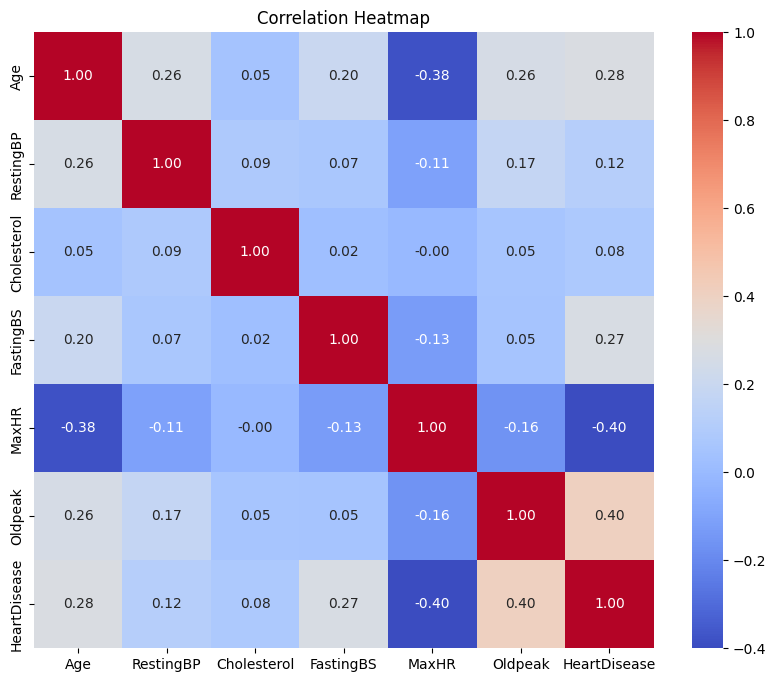

In [63]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

### Correlation Analysis Insight:

The correlation analysis shows that Oldpeak has the strongest positive correlation with HeartDisease (0.40), while MaxHR has the strongest negative correlation (-0.40). Age and FastingBS show weaker positive relationships with HeartDisease. Cholesterol shows a very weak positive correlation (0.08). These correlations describe associations within this dataset and do not imply causation.

# Outliner Detection:
We'll use the IQR (Interquartile Range) method for the numerical variables where outliers are relevant:

1. RestingBP
2. Cholesterol
3. Oldpeak
4. MaxHR

In [64]:
outlier_columns = ["RestingBP", "Cholesterol", "Oldpeak", "MaxHR"]

for col in outlier_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    
    print(f"\n{col}")
    print("Q1:", Q1)
    print("Q3:", Q3)
    print("IQR:", IQR)
    print("Lower Bound:", lower_bound)
    print("Upper Bound:", upper_bound)
    print("Number of Outliers:", len(outliers))


RestingBP
Q1: 120.0
Q3: 140.0
IQR: 20.0
Lower Bound: 90.0
Upper Bound: 170.0
Number of Outliers: 27

Cholesterol
Q1: 214.0
Q3: 267.0
IQR: 53.0
Lower Bound: 134.5
Upper Bound: 346.5
Number of Outliers: 41

Oldpeak
Q1: 0.0
Q3: 1.5
IQR: 1.5
Lower Bound: -2.25
Upper Bound: 3.75
Number of Outliers: 16

MaxHR
Q1: 120.0
Q3: 156.0
IQR: 36.0
Lower Bound: 66.0
Upper Bound: 210.0
Number of Outliers: 2


### Outlier Detection:

The IQR method was used to detect potential outliers in RestingBP, Cholesterol, Oldpeak, and MaxHR. Outliers were identified based on values falling below the lower bound or above the upper bound. Cholesterol had the highest number of detected outliers (41), followed by RestingBP (27), Oldpeak (16), and MaxHR (2).

# Outliner Treatment:

In [6]:
outlier_columns = ["RestingBP", "Cholesterol", "Oldpeak", "MaxHR"]

for col in outlier_columns:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    median = df[col].median()

    # Identify outliers
    outlier_mask = (df[col] < lower_bound) | (df[col] > upper_bound)

    print(col, "outliers before treatment:", outlier_mask.sum())

    # Replace outliers with median
    df.loc[outlier_mask, col] = median

    print(col, "median used:", median)

RestingBP outliers before treatment: 28
RestingBP median used: 130.0
Cholesterol outliers before treatment: 183
Cholesterol median used: 223.0
Oldpeak outliers before treatment: 16
Oldpeak median used: 0.6
MaxHR outliers before treatment: 2
MaxHR median used: 138.0


In [7]:
for col in outlier_columns:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    remaining = (
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ).sum()

    print(col, "remaining outliers:", remaining)

RestingBP remaining outliers: 0
Cholesterol remaining outliers: 39
Oldpeak remaining outliers: 0
MaxHR remaining outliers: 0


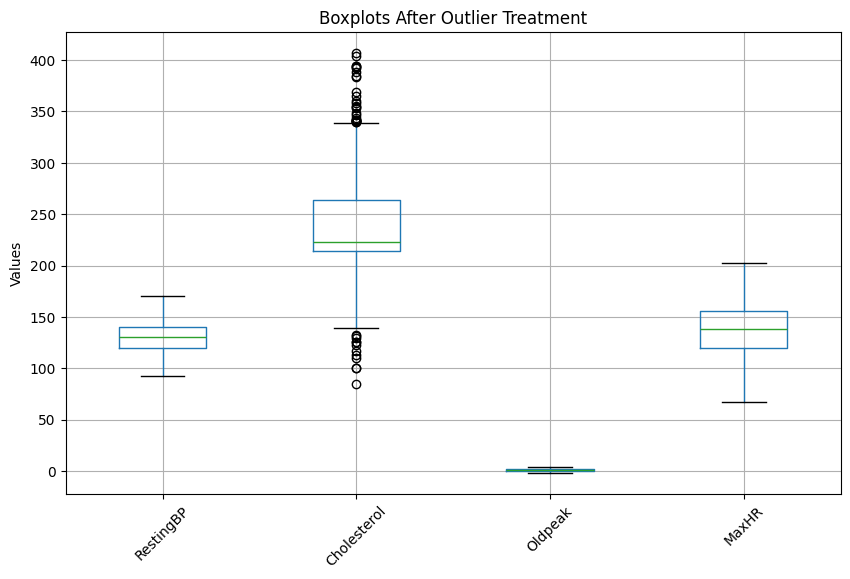

In [8]:
plt.figure(figsize=(10, 6))

df[["RestingBP", "Cholesterol", "Oldpeak", "MaxHR"]].boxplot()

plt.title("Boxplots After Outlier Treatment")
plt.ylabel("Values")
plt.xticks(rotation=45)

plt.show()

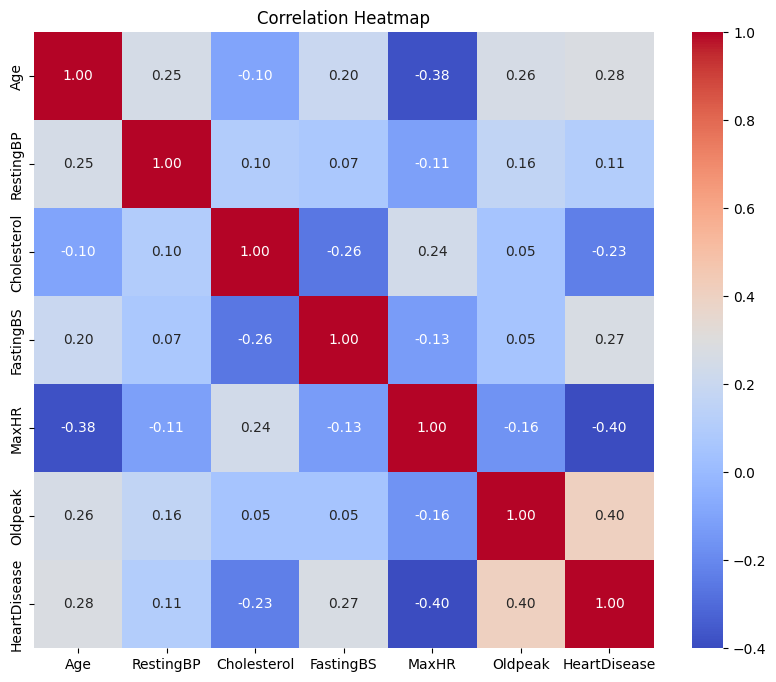

In [3]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

# After Cleaning the Dataset:

In [11]:
df.isnull().sum()


Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.shape

(918, 12)

# Model Training begins:

In [14]:
### splitting dataset into independent and dependent variables
X=df.iloc[:,:-1]
y=df.iloc[:,-1]

In [15]:
X.dtypes

Age                 int64
Sex                object
ChestPainType      object
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG         object
MaxHR               int64
ExerciseAngina     object
Oldpeak           float64
ST_Slope           object
dtype: object

In [16]:
cat_cols = X.select_dtypes(include="object").columns

for col in cat_cols:
    print(col, ":", X[col].unique())

Sex : ['M' 'F']
ChestPainType : ['ATA' 'NAP' 'ASY' 'TA']
RestingECG : ['Normal' 'ST' 'LVH']
ExerciseAngina : ['N' 'Y']
ST_Slope : ['Up' 'Flat' 'Down']


In [23]:
X

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up
...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat


In [17]:
y

0      0
1      1
2      0
3      1
4      0
      ..
913    1
914    1
915    1
916    1
917    0
Name: HeartDisease, Length: 918, dtype: int64

### Logistic Regression works with numerical input features, not raw text categories. we need to represent these categories numerically. We need encoding.

In [18]:
X = pd.get_dummies(X, columns=cat_cols, drop_first=True, dtype=int)

In [50]:
X.dtypes

Age                    int64
RestingBP              int64
Cholesterol            int64
FastingBS              int64
MaxHR                  int64
Oldpeak              float64
Sex_M                  int64
ChestPainType_ATA      int64
ChestPainType_NAP      int64
ChestPainType_TA       int64
RestingECG_Normal      int64
RestingECG_ST          int64
ExerciseAngina_Y       int64
ST_Slope_Flat          int64
ST_Slope_Up            int64
dtype: object

In [11]:
### train and test split:
from sklearn.model_selection import train_test_split

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

In [20]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(734, 15)
(184, 15)
(734,)
(184,)


## Scaling the Numerical Feautures: 

In [21]:
from sklearn.preprocessing import StandardScaler

num_cols = [
    "Age", "RestingBP", "Cholesterol",
    "MaxHR", "Oldpeak"]

scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [22]:
X_train[num_cols].describe()

,Age,RestingBP,Cholesterol,MaxHR,Oldpeak
count,7.340000e+02,7.340000e+02,7.340000e+02,7.340000e+02,7.340000e+02
mean,2.105491e-16,-6.389076e-16,-3.448649e-17,-1.270555e-16,8.107351e-17
std,1.000682e+00,1.000682e+00,1.000682e+00,1.000682e+00,1.000682e+00
min,-2.633920e+00,-2.262267e+00,-1.876035e+00,-2.958679e+00,-3.280610e+00
25%,-7.259563e-01,-7.125666e-01,-2.144180e-01,-6.731586e-01,-8.190561e-01
50%,1.220277e-01,-1.591022e-01,2.009863e-01,6.285629e-02,-3.456804e-01
75%,7.580156e-01,4.497087e-01,6.140828e-01,7.601336e-01,6.010711e-01
max,2.453983e+00,3.715149e+00,3.690382e+00,2.542064e+00,4.482752e+00


In [23]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use i

In [24]:
coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": model.coef_[0]
})

print(coef_df)

              Feature  Coefficient
0                 Age     0.035100
1           RestingBP     0.035133
2         Cholesterol    -0.489105
3           FastingBS     0.932745
4               MaxHR    -0.200707
5             Oldpeak     0.289380
6               Sex_M     1.103799
7   ChestPainType_ATA    -1.462495
8   ChestPainType_NAP    -1.678922
9    ChestPainType_TA    -1.140218
10  RestingECG_Normal    -0.342724
11      RestingECG_ST    -0.315640
12   ExerciseAngina_Y     0.901841
13      ST_Slope_Flat     0.990045
14        ST_Slope_Up    -1.385879


### making predictions:

In [25]:
y_pred = model.predict(X_test)

In [26]:
print(y_pred[:10])
print(y_test[:10].values)

[1 0 1 1 0 0 0 1 0 1]
[1 1 1 1 0 0 0 1 0 1]


## calculating the accuracy

In [27]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print(accuracy)
 # measure of how well the model is performing.
 # It is the ratio of correctly predicted observations to the total observations.

0.8858695652173914


In [28]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[68 14]
 [ 7 95]]


In [29]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.83      0.87        82
           1       0.87      0.93      0.90       102

    accuracy                           0.89       184
   macro avg       0.89      0.88      0.88       184
weighted avg       0.89      0.89      0.89       184



In [30]:
y_prob = model.predict_proba(X_test)
print(y_prob[:5])

[[0.0217745  0.9782255 ]
 [0.85111477 0.14888523]
 [0.0394359  0.9605641 ]
 [0.41796474 0.58203526]
 [0.82755057 0.17244943]]


In [7]:
import joblib

In [31]:
joblib.dump(model,"heart_disease_model.pkl")

['heart_disease_model.pkl']

In [32]:
loaded_model = joblib.load("heart_disease_model.pkl")

In [33]:
predictions = loaded_model.predict(X_test)

In [34]:
print(predictions[:10])
print(y_pred[:10])

[1 0 1 1 0 0 0 1 0 1]
[1 0 1 1 0 0 0 1 0 1]


In [35]:
from sklearn.metrics import accuracy_score

print(accuracy_score(y_test, predictions))

0.8858695652173914


In [36]:
model_bundle = {
    "model": model,
    "scaler": scaler,
    "feature_columns": X.columns.tolist()
}

joblib.dump(model_bundle, "heart_model_bundle.pkl")

['heart_model_bundle.pkl']

In [4]:
import os

print(os.path.exists("heart_model_bundle.pkl"))

True
